In [1]:
from unsloth import FastModel
from unsloth.chat_templates import get_chat_template
from datasets import Dataset
import torch

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from pythainlp.tokenize import word_tokenize

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
import glob
import json

import faiss
from langchain.vectorstores import FAISS
from langchain_huggingface.embeddings import HuggingFaceEmbeddings

ROOT_DIR = "/project/lt200304-dipmt/paweekorn"
MODEL_ID = "gemma3-4b-pt"

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
INFO 11-04 15:20:29 [__init__.py:241] Automatically detected platform cuda.


## Overview

In [2]:
train_df = pd.read_csv('/project/lt200304-dipmt/paweekorn/data/train_40k.csv')
test_df = pd.read_csv("/project/lt200304-dipmt/paweekorn/data/test_set.csv")

with open('/project/lt200304-dipmt/paweekorn/data/wipo/WIPO.json', 'r') as f:
    wipo_data = json.load(f)
    wipo_data = {int(k): v for k, v in wipo_data.items()}

train_df['WIPO'] = train_df['NAME'].map(wipo_data)
test_df['WIPO'] = test_df['NAME'].map(wipo_data)

train_df.drop_duplicates(subset=['ENG', 'THA'], inplace=True)

print(train_df.shape)
train_df.head()

(39706, 4)


,ENG,THA,NAME,WIPO
0,"condiment, namely, pepper sauce","เครื่องปรุงรส, คือ, ซอสพริกไทย",30,"Coffee, tea, cocoa and substitutes therefor; r..."
1,machine and motor oil,น้ำมันเครื่องและมอเตอร์,4,Industrial oils and greases; lubricants; dust ...
2,medical analysis for diagnostic or treatment p...,วิเคราะห์ทางการแพทย์เพื่อการวินิจฉัยหรือการรักษา,44,Medical services; veterinary services; hygieni...
3,cleaning preparation for window pane,สารเตรียมขึ้นสำหรับทำความสะอาดบานกระจกหน้าต่าง,3,Non-medicated cosmetics and toiletry preparati...
4,protective padding for sport,แผ่นป้องกันสำหรับกีฬา,28,"Games, toys and playthings; video game apparat..."


In [3]:
model, tokenizer = FastModel.from_pretrained(
    model_name = f"{ROOT_DIR}/models/base/{MODEL_ID}/",
    max_seq_length = 2048,
    load_in_4bit = True,
    load_in_8bit = False,
    full_finetuning = False,
    device_map="balanced",
)

==((====))==  Unsloth 2025.8.4: Fast Gemma3 patching. Transformers: 4.55.0. vLLM: 0.10.1.1.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 2. Max memory: 39.496 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.1+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.3.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.31. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## Data Prep

In [4]:
retriever = "all-MiniLM-L6-v2"
embeddings = HuggingFaceEmbeddings(model_name=f"{ROOT_DIR}/models/retriever/{retriever}")
vectorstore = FAISS.load_local(
    f"{ROOT_DIR}/vector/{retriever}",
    embeddings,
    allow_dangerous_deserialization=True
)
gpu_index = faiss.index_cpu_to_gpu(faiss.StandardGpuResources(), 0, vectorstore.index)
vectorstore.index = gpu_index

In [5]:
tokenizer = get_chat_template(tokenizer, "gemma-3")
with open(f"{ROOT_DIR}/data/prompt/base_prompt.txt") as f:
    instruction = f.read()

def get_relevant_docs(query, k=4):
    query_embedding = embeddings.embed_query(query)
    docs = vectorstore.similarity_search_by_vector(query_embedding, k=k)
    
    relevant = "\n**Retrieved References:**\n"
    for i, doc in enumerate(docs[1:]):
        relevant += f'''
English: {doc.page_content}
Thai: {doc.metadata['thai']}
'''
    return relevant

def formatting_prompt(df):
    batch = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        prompt = [
            { "role": "user", "content": instruction.format(
                WIPO=row['WIPO'], 
                RAG_DOC=get_relevant_docs(row['ENG'], 3), 
                ENGLISH=row['ENG']) }, 
            { "role": "assistant", "content": 
              f'''{{"thai_translation": "{row['THA']}"}}'''
            }
        ]
        message = tokenizer.apply_chat_template(prompt, tokenize=False, add_generation_prompt=False)
        batch.append({'text': message})

    return Dataset.from_list(batch)

train_set = formatting_prompt(train_df)
test_set = formatting_prompt(test_df)
print(train_set['text'][0])

100%|██████████| 8392/8392 [00:54<00:00, 152.70it/s]


<bos><start_of_turn>user
## Instructions:
You are an expert in the classification of goods and services under the WIPO Nice Classification system. Your task is to translate product names from English to accurate and direct Thai.

**Translation Guidelines:**
- Maintain the punctuation alignment of the input text.
- Use Thai legal and commercial terminology appropriate for trademarks and product classification.
- Do not include explanations, commentary, or any information beyond the translation output.
- Provided output in the format of {"thai_translation": "Thai translation"}

**Product Domain:**
Coffee, tea, cocoa and substitutes therefor; rice, pasta and noodles; tapioca and sago; flour and preparations made from cereals; bread, pastries and confectionery; chocolate; ice cream, sorbets and other edible ices; sugar, honey, treacle; yeast, baking-powder; salt, seasonings, spices, preserved herbs; vinegar, sauces and other condiments; ice (frozen water).

**Retrieved References:**

Engli

## Model Training

In [6]:
model = FastModel.get_peft_model(
    model, 
    finetune_vision_layers     = False,
    finetune_language_layers   = True,
    finetune_attention_modules = True,  # Attention good for GRPO
    finetune_mlp_modules       = True,
    
    r = 64,           
    lora_alpha = 64,  
    lora_dropout = 0,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"],
    bias = "none",
    random_state = 3407,
)

Unsloth: Making `base_model.model.model.vision_tower.vision_model` require gradients


In [7]:
from trl import SFTTrainer, SFTConfig

args = SFTConfig(
    output_dir=f"{ROOT_DIR}/models/adapter/{MODEL_ID}",
    overwrite_output_dir=True,
    dataset_text_field = "text",
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 32,
    gradient_accumulation_steps = 2,
    warmup_ratio = 0.03,
    num_train_epochs = 2,
    learning_rate = 2e-5,
    logging_steps = 200,
    eval_steps = 200,
    eval_strategy = "steps",
    save_steps = 300,
    save_strategy="steps",
    optim = "adamw_8bit",
    weight_decay = 0.01,
    lr_scheduler_type = "cosine",
    seed = 3407,
    report_to = "none",
)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_set,
    eval_dataset = test_set,
    args = args,
    gradient_checkpoint=True,
)

train_stats = trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/39706 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/8392 [00:00<?, ? examples/s]

[2025-11-04 15:40:39,573] [INFO] [real_accelerator.py:260:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/lustrefs/disk/home/psoratya/.conda/envs/unsloth_env/bin/../lib/gcc/x86_64-conda-linux-gnu/12.4.0/../../../../x86_64-conda-linux-gnu/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/lustrefs/disk/home/psoratya/.conda/envs/unsloth_env/bin/../lib/gcc/x86_64-conda-linux-gnu/12.4.0/../../../../x86_64-conda-linux-gnu/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status


[2025-11-04 15:40:47,376] [INFO] [logging.py:107:log_dist] [Rank -1] [TorchCheckpointEngine] Initialized with serialization = False


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 2
   \\   /|    Num examples = 39,706 | Num Epochs = 2 | Total steps = 1,242
O^O/ \_/ \    Batch size per device = 32 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (32 x 2 x 1) = 64
 "-____-"     Trainable parameters = 131,153,920 of 4,431,233,392 (2.96% trained)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
100,1.066500,0.374849
200,0.306500,0.351816


Unsloth: Not an error, but Gemma3ForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


KeyboardInterrupt: 

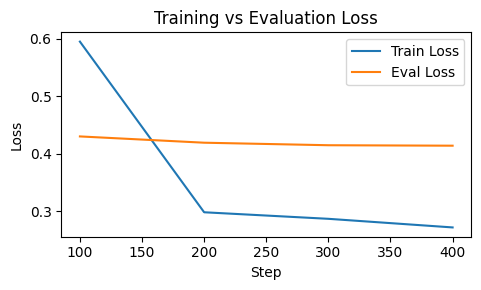

In [11]:
checkpoints = glob.glob(f"{ROOT_DIR}/models/fine-tuned/{MODEL_ID}/checkpoint*")
sorted_checkpoints = sorted(checkpoints, key=lambda x: int(x.split('-')[-1]))
with open(f"{sorted_checkpoints[-1]}/trainer_state.json") as f:
    stats = json.load(f)

stat_df = pd.DataFrame(stats['log_history'])
stat_df = stat_df.groupby("step", as_index=False).agg(lambda x: x.dropna().iloc[0] if x.dropna().size else None)

# Plot
plt.figure(figsize=(5, 3))
plt.plot(stat_df["step"], stat_df["loss"], label="Train Loss")
plt.plot(stat_df["step"],  stat_df["eval_loss"], label="Eval Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Evaluation Loss")
plt.legend()
plt.tight_layout()
plt.show()